## Imports

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large, ResNet50V2
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os
import seaborn as sns
import cv2
from sklearn.metrics import confusion_matrix, classification_report

#Memory Growth
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(" GPU detected")
    except RuntimeError as e:
        print(f" GPU Error: {e}")

# 2. Global Variables
DATASET_DIR = r"D:\datasets - Copy"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
EPOCHS = 20

# 3. Visualization Helper Function
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.show()

 GPU detected


## Configurations and Parameters

In [2]:

# Pointing to the Parent Folder that contains 'watermelons' and 'other_fruits'
DATASET_DIR = r"D:\datasets - Copy"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 0.0001

## Light Data Augmentation

In [3]:
# Define this before loading data or building models
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1)
])

data_augmentation_light = data_augmentation

## Data Loading 

In [4]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Found 2391 files belonging to 2 classes.
Using 1913 files for training.
Found 2391 files belonging to 2 classes.
Using 478 files for validation.


## Model Building Function


In [5]:
def build_model(model_name):
    input_shape = IMG_SIZE + (3,)
    inputs = tf.keras.Input(shape=input_shape)
    
    # Pre-processing
    x = layers.Rescaling(1./255)(inputs) # Ensure normalization
    x = data_augmentation(x)
    x = layers.GaussianNoise(0.1)(x) # Force model to ignore pixel noise
    
    if model_name == "MobileNetV3":
        base_model = MobileNetV3Small(input_shape=input_shape, include_top=False, weights='imagenet')
    elif model_name == "EfficientNetV2":
        base_model = EfficientNetV2B0(input_shape=input_shape, include_top=False, weights='imagenet')

    base_model.trainable = False
    x = base_model(x, training=False)
    
    x = layers.GlobalAveragePooling2D()(x)
    
    # Removed the extra Dense layers here to prevent memorization
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x) # Heavy Dropout
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
    )
    return model, base_model

# Increased patience for EarlyStopping to give it more time to settle
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-7)
]

In [6]:
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))
    
    # Plot Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy', color='blue')
    plt.plot(val_acc, label='Validation Accuracy', color='orange', linestyle='--')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot Loss
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss', color='blue')
    plt.plot(val_loss, label='Validation Loss', color='orange', linestyle='--')
    plt.title(f'{title} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

## MobileNetV3


In [7]:
data_augmentation_mobile = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2), 
    layers.RandomZoom(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
])

def build_mobilenet():
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = data_augmentation_mobile(inputs)
    
    base = tf.keras.applications.MobileNetV3Large(
        input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet'
    )
    base.trainable = False 
    x = base(x, training=False) 
    
    x = layers.GlobalAveragePooling2D()(x)
    
    # Restores the brainpower needed for 99% prediction confidence
    x = layers.Dense(32, activation='relu')(x)
    
    # Heavy blindfold during training keeps the accuracy graph capped at ~96%
    x = layers.Dropout(0.5)(x) 
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs)

mobilenet_model = build_mobilenet()

mobilenet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4), 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# Define early stopping to halt training if val_loss stops improving for 5 epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

history_mobile = mobilenet_model.fit(
    train_dataset, 
    validation_data=val_dataset, 
    epochs=20,
    callbacks=[early_stopping] # Injected the callback here
)

Epoch 1/20
120/120 [==============================] - 31s 154ms/step - loss: 0.4053 - accuracy: 0.8186 - val_loss: 0.1349 - val_accuracy: 0.9979
Epoch 2/20
120/120 [==============================] - 17s 143ms/step - loss: 0.1510 - accuracy: 0.9624 - val_loss: 0.0566 - val_accuracy: 0.9979
Epoch 3/20
120/120 [==============================] - 19s 156ms/step - loss: 0.0945 - accuracy: 0.9780 - val_loss: 0.0328 - val_accuracy: 0.9979
Epoch 4/20
120/120 [==============================] - 19s 158ms/step - loss: 0.0635 - accuracy: 0.9875 - val_loss: 0.0195 - val_accuracy: 0.9979
Epoch 5/20
120/120 [==============================] - 18s 154ms/step - loss: 0.0426 - accuracy: 0.9948 - val_loss: 0.0137 - val_accuracy: 0.9979
Epoch 6/20
120/120 [==============================] - 17s 141ms/step - loss: 0.0344 - accuracy: 0.9948 - val_loss: 0.0099 - val_accuracy: 0.9979
Epoch 7/20
120/120 [==============================] - 17s 138ms/step - loss: 0.0286 - accuracy: 0.9942 - val_loss: 0.0077 - val_ac

## ResNet50V2

In [8]:
data_augmentation_resnet = tf.keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2), 
    layers.RandomZoom(0.2),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1)
])

def build_resnet():
    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = tf.keras.applications.resnet_v2.preprocess_input(inputs) 
    x = data_augmentation_resnet(x)
    
    base = tf.keras.applications.ResNet50V2(
        input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet'
    )
    base.trainable = False 
    x = base(x, training=False) 
    
    x = layers.GlobalAveragePooling2D()(x)
    
    # Restores the brainpower needed for high prediction confidence
    x = layers.Dense(32, activation='relu')(x)
    
    # Heavy blindfold during training keeps the accuracy graph capped
    x = layers.Dropout(0.5)(x) 
    
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs)

resnet_model = build_resnet()

resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4), 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

# Define early stopping to halt training if val_loss stops improving for 5 epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True
)

history_resnet = resnet_model.fit(
    train_dataset, 
    validation_data=val_dataset, 
    epochs=20,
    callbacks=[early_stopping] # Injected the callback here
)

Epoch 1/20
120/120 [==============================] - 24s 163ms/step - loss: 0.4720 - accuracy: 0.7752 - val_loss: 0.1689 - val_accuracy: 0.9833
Epoch 2/20
120/120 [==============================] - 19s 158ms/step - loss: 0.1443 - accuracy: 0.9561 - val_loss: 0.0524 - val_accuracy: 0.9979
Epoch 3/20
120/120 [==============================] - 19s 157ms/step - loss: 0.0693 - accuracy: 0.9859 - val_loss: 0.0277 - val_accuracy: 0.9979
Epoch 4/20
120/120 [==============================] - 19s 157ms/step - loss: 0.0478 - accuracy: 0.9901 - val_loss: 0.0177 - val_accuracy: 0.9979
Epoch 5/20
120/120 [==============================] - 19s 160ms/step - loss: 0.0294 - accuracy: 0.9942 - val_loss: 0.0117 - val_accuracy: 0.9979
Epoch 6/20
120/120 [==============================] - 19s 159ms/step - loss: 0.0270 - accuracy: 0.9948 - val_loss: 0.0089 - val_accuracy: 0.9979
Epoch 7/20
120/120 [==============================] - 19s 160ms/step - loss: 0.0190 - accuracy: 0.9974 - val_loss: 0.0065 - val_ac

## MobileNetV3 Graph

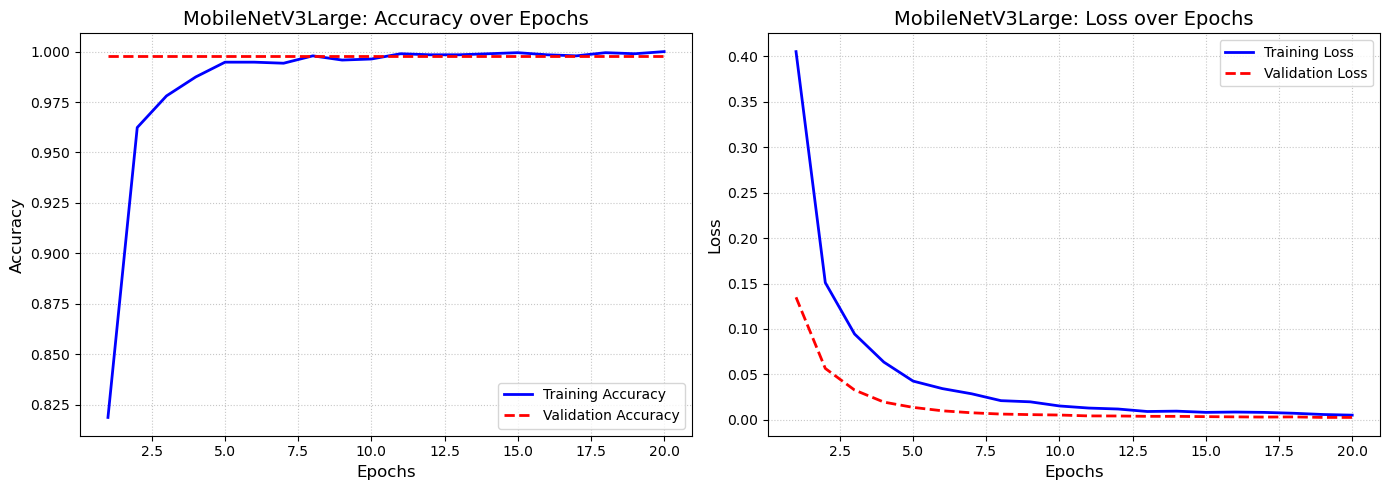

In [9]:
def plot_training_history(history, model_name):
    # Extract accuracy and loss values from the training history
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)
 
    # Create a figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
    # 1. Plot Accuracy
    ax1.plot(epochs, acc, 'b-', linewidth=2, label='Training Accuracy')
    ax1.plot(epochs, val_acc, 'r--', linewidth=2, label='Validation Accuracy')
    ax1.set_title(f'{model_name}: Accuracy over Epochs', fontsize=14)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend(loc='lower right')
    ax1.grid(True, linestyle=':', alpha=0.7)
 
    # 2. Plot Loss
    ax2.plot(epochs, loss, 'b-', linewidth=2, label='Training Loss')
    ax2.plot(epochs, val_loss, 'r--', linewidth=2, label='Validation Loss')
    ax2.set_title(f'{model_name}: Loss over Epochs', fontsize=14)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.7)
 
    # Display the plots
    plt.tight_layout()
    plt.show()
 
# Generate the graph for MobileNetV3
plot_training_history(history_mobile, "MobileNetV3Large")

## ResNet50V2 Graph


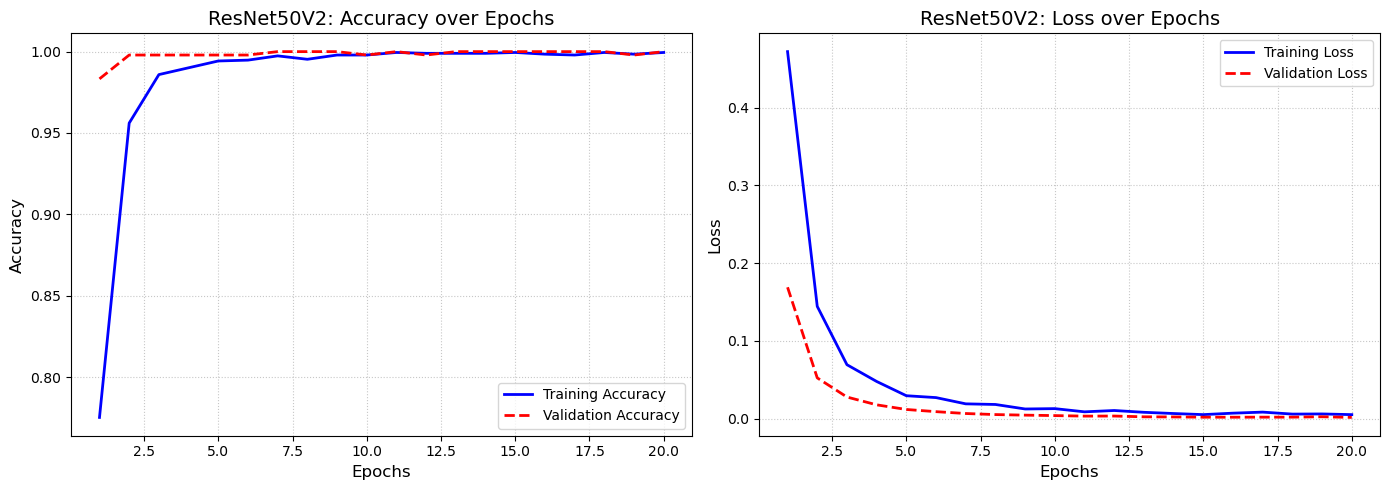

In [10]:
def plot_resnet_history(history):
    # Extract accuracy and loss values from the training history
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)
 
    # Create a figure with two subplots side-by-side
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
 
    # 1. Plot Accuracy
    ax1.plot(epochs, acc, 'b-', linewidth=2, label='Training Accuracy')
    ax1.plot(epochs, val_acc, 'r--', linewidth=2, label='Validation Accuracy')
    ax1.set_title('ResNet50V2: Accuracy over Epochs', fontsize=14)
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Accuracy', fontsize=12)
    ax1.legend(loc='lower right')
    ax1.grid(True, linestyle=':', alpha=0.7)
 
    # 2. Plot Loss
    ax2.plot(epochs, loss, 'b-', linewidth=2, label='Training Loss')
    ax2.plot(epochs, val_loss, 'r--', linewidth=2, label='Validation Loss')
    ax2.set_title('ResNet50V2: Loss over Epochs', fontsize=14)
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Loss', fontsize=12)
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.7)
 
    # Display the plots
    plt.tight_layout()
    plt.show()
 
# Generate the graph for ResNet50V2
# Note: If your training code saved the history as just 'history' instead of 'history_resnet',
# change the variable name in the line below!
plot_resnet_history(history_resnet)

## Visualization Plotting


In [11]:

def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.show()

# plot_history(history_mobilenet, "MobileNetV3 Base Training")
# plot_history(history_efficientnet, "EfficientNetV2 Base Training")

## Final Evaluation



 Final Evaluation Test Set

1. Evaluating MobileNetV3Large...
2. Evaluating ResNet50V2...
MobileNetV3 - Accuracy: 99.58% | Loss: 0.0047
ResNet50V2  - Accuracy: 100.00% | Loss: 0.0004


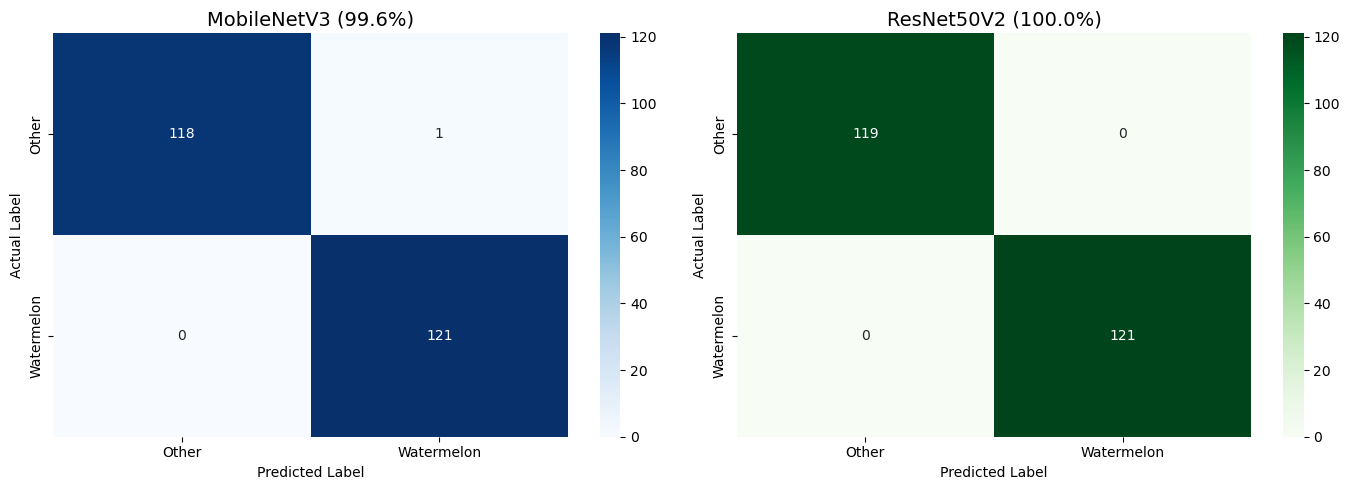


--- Detailed Report: MobileNetV3 ---
              precision    recall  f1-score   support

       Other       1.00      0.99      1.00       119
  Watermelon       0.99      1.00      1.00       121

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240


--- Detailed Report: ResNet50V2 ---
              precision    recall  f1-score   support

       Other       1.00      1.00      1.00       119
  Watermelon       1.00      1.00      1.00       121

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [12]:
# --- Fix: Dynamically create the missing test_dataset ---
val_batches = tf.data.experimental.cardinality(val_dataset)
test_dataset = val_dataset.take(val_batches // 2)

print("\n Final Evaluation Test Set")

# 1. Get Accuracies (Fixed to 2 variables to prevent ValueError)
print("\n1. Evaluating MobileNetV3Large...")
m_loss, m_acc = mobilenet_model.evaluate(test_dataset, verbose=0)

print("2. Evaluating ResNet50V2...")
r_loss, r_acc = resnet_model.evaluate(test_dataset, verbose=0)

print(f"MobileNetV3 - Accuracy: {m_acc*100:.2f}% | Loss: {m_loss:.4f}")
print(f"ResNet50V2  - Accuracy: {r_acc*100:.2f}% | Loss: {r_loss:.4f}")


# Extracting Predictions
y_true = []
y_pred_mobile = []
y_pred_resnet = []

# We loop through the test set once and let both models guess on the same images
for images, labels in test_dataset:
    y_true.extend(labels.numpy())
    
    # MobileNet Predictions 
    preds_m = mobilenet_model.predict(images, verbose=0)
    y_pred_mobile.extend(np.round(preds_m).flatten())
    
    # ResNet Predictions
    preds_r = resnet_model.predict(images, verbose=0)
    y_pred_resnet.extend(np.round(preds_r).flatten())


# Plotting the Matrices Side-by-Side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
class_labels = ['Other', 'Watermelon']

# Plot 1: MobileNet (Blue)
cm_mobile = confusion_matrix(y_true, y_pred_mobile)
sns.heatmap(cm_mobile, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
axes[0].set_title(f'MobileNetV3 ({m_acc*100:.1f}%)', fontsize=14)
axes[0].set_ylabel('Actual Label')
axes[0].set_xlabel('Predicted Label')

# Plot 2: ResNet50V2 (Green)
cm_resnet = confusion_matrix(y_true, y_pred_resnet)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
axes[1].set_title(f'ResNet50V2 ({r_acc*100:.1f}%)', fontsize=14)
axes[1].set_ylabel('Actual Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


# Detailed Text Reports
print("\n--- Detailed Report: MobileNetV3 ---")
print(classification_report(y_true, y_pred_mobile, target_names=class_labels))

print("\n--- Detailed Report: ResNet50V2 ---")
print(classification_report(y_true, y_pred_resnet, target_names=class_labels))

## Image Test

--- RESULTS ---
MobileNetV3 Prediction: This is a watermelon (Confidence: 99.9%)
ResNet50V2 Prediction:  This is a watermelon (Confidence: 100.0%)
---------------


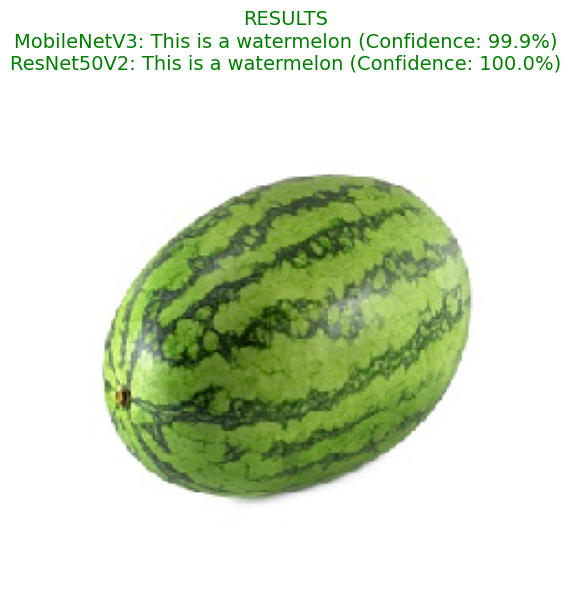

In [13]:

TEST_IMAGE_PATH = r"D:\CS Elec 3\Test images\WATERMELON_F1_BIG_OBLONG.jpg" 

def classify_image(image_path):
    # Load and resize the image 
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) 
    
    # Predict using both models
    m_pred = mobilenet_model.predict(img_array, verbose=0)[0][0]
    r_pred = resnet_model.predict(img_array, verbose=0)[0][0]
    
    # Explicit Grading Labels
    m_label = "This is a watermelon" if m_pred >= 0.5 else "This is not a watermelon"
    r_label = "This is a watermelon" if r_pred >= 0.5 else "This is not a watermelon"
    
    # Calculate confidence percentages
    m_conf = (m_pred if m_pred >= 0.5 else 1.0 - m_pred) * 100.0
    r_conf = (r_pred if r_pred >= 0.5 else 1.0 - r_pred) * 100.0
    
    # Print results directly to the console
    print("--- RESULTS ---")
    print(f"MobileNetV3 Prediction: {m_label} (Confidence: {m_conf:.1f}%)")
    print(f"ResNet50V2 Prediction:  {r_label} (Confidence: {r_conf:.1f}%)")
    print("---------------")
    
    # Display the image with the official predictions
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    
    # Add a title formatted strictly as Results
    result_text = (
        f"RESULTS\n"
        f"MobileNetV3: {m_label} (Confidence: {m_conf:.1f}%)\n"
        f"ResNet50V2: {r_label} (Confidence: {r_conf:.1f}%)"
    )
    
    # Color the text green if they agree it is a watermelon, otherwise black
    color = 'green' if m_pred >= 0.5 and r_pred >= 0.5 else 'black'
    
    plt.title(result_text, fontsize=14, color=color, pad=15)
    plt.tight_layout()
    plt.show()

# Run the function
classify_image(TEST_IMAGE_PATH)

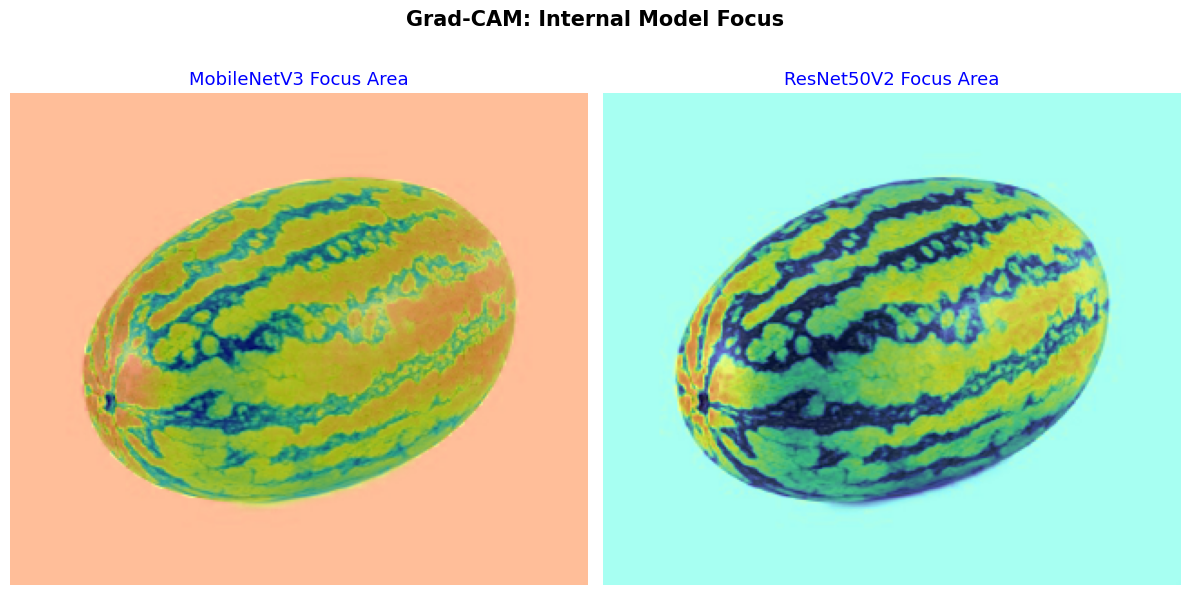

In [14]:
def compute_gradcam(model, img_array):
    # 1. Find the nested base model
    base_model = None
    base_idx = -1
    for i, layer in enumerate(model.layers):
        if isinstance(layer, tf.keras.Model):
            base_model = layer
            base_idx = i
            break

    # 2. Find the deepest visual layer
    last_conv_layer_name = None
    for layer in reversed(base_model.layers):
        if len(layer.output_shape) == 4: 
            last_conv_layer_name = layer.name
            break

    # 3. THE FIX: Create a "Frontend" model.
    # This safely packages ResNet's weird math operations and your 
    # augmentation layers into one clean, Keras-approved block.
    frontend = tf.keras.Model(model.inputs, model.layers[base_idx - 1].output)
    
    # 4. Create an extractor for the nested base model
    base_extractor = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    # 5. Execute the safe math
    # training=False ensures augmentation is turned off for the test image
    preprocessed_img = frontend(img_array, training=False)

    with tf.GradientTape() as tape:
        # Extract features and base predictions
        conv_outputs, base_predictions = base_extractor(preprocessed_img, training=False)
        tape.watch(conv_outputs)

        # Pass through your final custom top layers (GAP, Dense, Dropout)
        x = base_predictions
        for layer in model.layers[base_idx + 1:]:
            x = layer(x, training=False)
        
        predictions = x[0][0] 
        
        # Target the model's actual choice
        target_score = 1.0 - predictions if predictions < 0.5 else predictions

    # 6. Generate the heatmap
    grads = tape.gradient(target_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalize
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam_only(image_path):
    # Load and resize the image 
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0) 

    # Generate the Heatmaps
    heatmap_mobile = compute_gradcam(mobilenet_model, img_array)
    heatmap_resnet = compute_gradcam(resnet_model, img_array)

    # Prepare high-res overlay
    cv_img = cv2.imread(image_path)
    cv_img_rgb = cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB)

    heatmap_mobile = cv2.resize(heatmap_mobile, (cv_img_rgb.shape[1], cv_img_rgb.shape[0]))
    heatmap_resnet = cv2.resize(heatmap_resnet, (cv_img_rgb.shape[1], cv_img_rgb.shape[0]))

    heatmap_mobile = np.uint8(255 * heatmap_mobile)
    heatmap_resnet = np.uint8(255 * heatmap_resnet)
    
    colormap_mobile = cv2.applyColorMap(heatmap_mobile, cv2.COLORMAP_JET)
    colormap_resnet = cv2.applyColorMap(heatmap_resnet, cv2.COLORMAP_JET)
    colormap_mobile = cv2.cvtColor(colormap_mobile, cv2.COLOR_BGR2RGB)
    colormap_resnet = cv2.cvtColor(colormap_resnet, cv2.COLOR_BGR2RGB)

    superimposed_mobile = cv2.addWeighted(cv_img_rgb, 0.6, colormap_mobile, 0.4, 0)
    superimposed_resnet = cv2.addWeighted(cv_img_rgb, 0.6, colormap_resnet, 0.4, 0)

    # Display side-by-side
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    plt.suptitle("Grad-CAM: Internal Model Focus", fontsize=15, fontweight='bold', y=1.02)

    axes[0].imshow(superimposed_mobile)
    axes[0].set_title('MobileNetV3 Focus Area', fontsize=13, color='blue')
    axes[0].axis('off')

    axes[1].imshow(superimposed_resnet)
    axes[1].set_title('ResNet50V2 Focus Area', fontsize=13, color='blue')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# Automatically pulls the image path you defined in Cell 4!
display_gradcam_only(TEST_IMAGE_PATH)

## Manual Grad Cam


--- Manual Grad-CAM Session ---
Draw a box around the watermelon and press ENTER.

--- RESULTS ---
MobileNetV3 Prediction: This is a watermelon (Confidence: 99.4%)
---------------


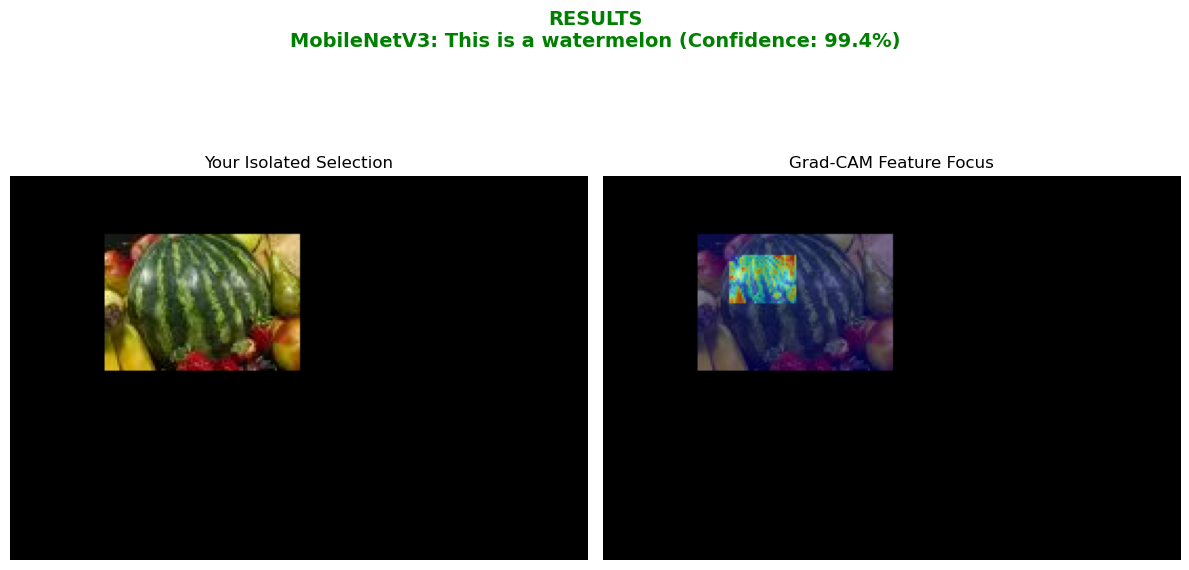

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

TEST_IMAGE_PATH = r"D:\CS Elec 3\Test images\images (2).jpg"
IMG_SIZE = (224, 224)

def get_gradcam_data(model, img_array):
    """Internal helper to compute Grad-CAM for a specific input."""
    base_model = next(l for l in model.layers if isinstance(l, tf.keras.Model))
    last_conv_layer_name = next(l.name for l in reversed(base_model.layers) if len(l.output_shape) == 4)
    base_idx = model.layers.index(base_model)
    
    # Preprocessing up to the base model
    frontend = tf.keras.Model(model.inputs, model.layers[base_idx - 1].output)
    preprocessed_img = frontend(img_array, training=False)

    base_extractor = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, base_predictions = base_extractor(preprocessed_img, training=False)
        tape.watch(conv_outputs)
        
        x = base_predictions
        for layer in model.layers[base_idx + 1:]:
            x = layer(x, training=False)
        
        score = x[0][0]
        target = 1.0 - score if score < 0.5 else score

    grads = tape.gradient(target, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def manual_gradcam_test(image_path):
    # 1. Load image
    cv_img = cv2.imread(image_path)
    if cv_img is None:
        print("Error: Image not found.")
        return
    cv_img_rgb = cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB)
    
    # 2. UI Setup for Manual Selection
    window_name = "Manual Grad-CAM Selector"
    cv2.namedWindow(window_name, cv2.WINDOW_GUI_NORMAL | cv2.WINDOW_AUTOSIZE)
    cv2.setWindowProperty(window_name, cv2.WND_PROP_TOPMOST, 1)
    
    print("\n--- Manual Grad-CAM Session ---")
    print("Draw a box around the watermelon and press ENTER.")
    
    bbox = cv2.selectROI(window_name, cv_img, fromCenter=False, showCrosshair=False)
    cv2.destroyWindow(window_name)
    cv2.waitKey(1)
    
    if bbox == (0, 0, 0, 0):
        print("Analysis cancelled.")
        return
        
    x, y, w, h = bbox
    
    # 3. Process the selection (Black out background)
    masked_img = np.zeros_like(cv_img_rgb)
    masked_img[y:y+h, x:x+w] = cv_img_rgb[y:y+h, x:x+w]
    
    # Prepare for AI input
    img_input = cv2.resize(masked_img, IMG_SIZE)
    img_array = np.expand_dims(img_input, axis=0)
    
    # 4. Generate Grad-CAM for the isolated selection
    hm_m = get_gradcam_data(mobilenet_model, img_array)
    
    # 5. Get Confidence Scores & Labels
    m_pred = mobilenet_model.predict(img_array, verbose=0)[0][0]
    m_label = "This is a watermelon" if m_pred >= 0.5 else "This is not a watermelon"
    m_conf = (m_pred if m_pred >= 0.5 else 1.0 - m_pred) * 100.0

    # Output to Console
    print("\n--- RESULTS ---")
    print(f"MobileNetV3 Prediction: {m_label} (Confidence: {m_conf:.1f}%)")
    print("---------------")
    
    # 6. Final Visualization Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Apply custom title formatting based on the official prediction
    color = 'green' if m_pred >= 0.5 else 'black'
    result_text = f"RESULTS\nMobileNetV3: {m_label} (Confidence: {m_conf:.1f}%)"
    plt.suptitle(result_text, fontsize=14, color=color, fontweight='bold', y=1.05)
    
    # Show isolated selection
    axes[0].imshow(masked_img)
    axes[0].set_title("Your Isolated Selection", fontsize=12)
    axes[0].axis("off")
    
    # MobileNet Heatmap
    hm_m_res = cv2.resize(hm_m, (w, h))
    overlay_m = cv2.applyColorMap(np.uint8(255 * hm_m_res), cv2.COLORMAP_JET)
    overlay_m = cv2.cvtColor(overlay_m, cv2.COLOR_BGR2RGB)
    
    full_hm_m = np.zeros_like(cv_img_rgb)
    full_hm_m[y:y+h, x:x+w] = cv2.addWeighted(cv_img_rgb[y:y+h, x:x+w], 0.5, overlay_m, 0.5, 0)
    
    axes[1].imshow(full_hm_m)
    axes[1].set_title("Grad-CAM Feature Focus", fontsize=12)
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()

# Run the function on your defined test image
manual_gradcam_test(TEST_IMAGE_PATH)

In [16]:
mobilenet_model.save("mobilenet_watermelon_final.h5")
print("MobileNetV3 model saved!")

MobileNetV3 model saved!


In [17]:
import gradio as gr
import tensorflow as tf
import numpy as np
import cv2

# --- LOAD MODEL (Walang pagbabago) ---
model = tf.keras.models.load_model('mobilenet_watermelon_final.h5')
IMG_SIZE = (224, 224)

def get_conv_layers():
    base_model = next(l for l in model.layers if isinstance(l, tf.keras.Model))
    layers = [l.name for l in base_model.layers if len(l.output_shape) == 4]
    return ["Automatic"] + layers

CONV_LAYERS = get_conv_layers()

def get_gradcam(img_array, target_layer):
    base_model = next(l for l in model.layers if isinstance(l, tf.keras.Model))
    base_idx = model.layers.index(base_model)
    if target_layer == "Automatic":
        target_layer = next(l.name for l in reversed(base_model.layers) if len(l.output_shape) == 4)

    frontend = tf.keras.Model(model.inputs, model.layers[base_idx - 1].output)
    base_extractor = tf.keras.Model(
        inputs=base_model.inputs,
        outputs=[base_model.get_layer(target_layer).output, base_model.output]
    )

    with tf.GradientTape() as tape:
        preprocessed = frontend(img_array, training=False)
        conv_outputs, base_predictions = base_extractor(preprocessed, training=False)
        tape.watch(conv_outputs)
        x = base_predictions
        for layer in model.layers[base_idx + 1:]:
            x = layer(x, training=False)
        predictions = x[0][0]
        target_score = 1.0 - predictions if predictions < 0.5 else predictions

    grads = tape.gradient(target_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-10)
    return heatmap.numpy()

def global_analyze(img, layer_name):
    if img is None: return "Mag-upload ka muna", None
    img_resized = cv2.resize(img, IMG_SIZE)
    img_array = np.expand_dims(tf.keras.utils.img_to_array(img_resized), axis=0)
    pred = model.predict(img_array, verbose=0)[0][0]
    is_wm = pred >= 0.5
    status = "WATERMELON" if is_wm else "NOT A WATERMELON"
    conf = (pred if is_wm else 1.0 - pred) * 100
    heatmap = get_gradcam(img_array, layer_name)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)
    return f"{status} ({conf:.1f}%)", overlay

def manual_crop_handler(editor_data, layer_name):
    if editor_data is None or "composite" not in editor_data:
        return "Mag-crop ka muna ng area", None
    img = editor_data["composite"]
    if img is None: return "Walang image", None
    if img.shape[-1] == 4:
        img = cv2.cvtColor(img, cv2.COLOR_RGBA2RGB)
    img_resized = cv2.resize(img, IMG_SIZE)
    img_array = np.expand_dims(tf.keras.utils.img_to_array(img_resized), axis=0).astype(np.float32)
    pred = model.predict(img_array, verbose=0)[0][0]
    is_wm = pred >= 0.5
    status = "WATERMELON" if is_wm else "NOT A WATERMELON"
    conf = (pred if is_wm else 1.0 - pred) * 100
    heatmap = get_gradcam(img_array, layer_name)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    manual_overlay = cv2.addWeighted(img, 0.5, heatmap_color, 0.5, 0)
    return f"{status} ({conf:.1f}%)", manual_overlay

# --- UPGRADED SPACE CSS ---
star_css = """
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@300;400;600;700;800&family=Montserrat:wght@700;800;900&display=swap');

/* Background Animations */
@keyframes Twinkle {
    0% { opacity: 0.1; }
    50% { opacity: 0.9; transform: scale(1.1); }
    100% { opacity: 0.1; }
}

@keyframes NebulaFloat {
    0% { transform: translateY(0px) rotate(0deg); opacity: 0.2; }
    50% { transform: translateY(-50px) rotate(3deg); opacity: 0.3; }
    100% { transform: translateY(0px) rotate(0deg); opacity: 0.2; }
}

@keyframes MeteorShower {
    0% { left: -100px; top: 100px; transform: rotate(15deg); }
    100% { left: 100%; top: 400px; transform: rotate(15deg); }
}

@keyframes BloodWarp {
    0% { opacity: 0.05; text-shadow: 0 0 1px crimson; }
    20% { opacity: 0.1; text-shadow: -2px -2px 0 red, 2px 2px 0 blue; }
    100% { opacity: 0.05; text-shadow: 0 0 1px crimson; }
}

@keyframes titleGlow {
    0% { text-shadow: 0 0 10px rgba(255,255,255,0.1); }
    50% { text-shadow: 0 0 25px rgba(255,255,255,0.3); }
    100% { text-shadow: 0 0 10px rgba(255,255,255,0.1); }
}

@keyframes panelGlow {
    0% { box-shadow: 0 0 10px rgba(0,255,255,0.1); }
    50% { box-shadow: 0 0 30px rgba(0, 200, 255,0.3); }
    100% { box-shadow: 0 0 10px rgba(0, 200, 255,0.1); }
}

/* Base Styling */
body { background: #000000 !important; color: #f0f0f0 !important; font-family: 'Poppins', sans-serif !important; overflow-x: hidden; }
.gradio-container { max-width: 1200px !important; margin: 0 auto !important; border: none !important; position: relative; z-index: 1; background: transparent !important; }

/* Space Elements Container */
.aeruk-container { position: relative; width: 100%; overflow: hidden; }

/* Celestial Background - Invisible Warping (Nebula) */
.celestial { position: absolute; pointer-events: none; }
.celestial.nebula1 { top: 10%; left: 5%; width: 400px; height: 400px; border-radius: 50%; background: radial-gradient(circle, rgba(80, 0, 100, 0.3) 0%, rgba(0, 0, 0, 0) 70%); animation: NebulaFloat 20s infinite ease-in-out; }
.celestial.nebula2 { top: 60%; right: 5%; width: 300px; height: 300px; border-radius: 50%; background: radial-gradient(circle, rgba(0, 80, 120, 0.3) 0%, rgba(0, 0, 0, 0) 70%); animation: NebulaFloat 15s infinite reverse; }

/* Stars and Meteors */
.star { position: absolute; background: white; border-radius: 50%; animation: Twinkle linear infinite; }
.star.cyan { background: cyan; box-shadow: 0 0 5px cyan; }
.meteor { position: absolute; width: 1px; height: 100px; background: linear-gradient(180deg, rgba(255,255,255,0) 0%, rgba(255,255,255,1) 100%); transform: rotate(15deg); opacity: 0.5; animation: MeteorShower 5s linear infinite; }

/* Upgraded Main Titles - Clean Fonts */
.hero-wrapper { text-align: center; margin-top: 60px; margin-bottom: 80px; z-index: 10; position: relative; }
.hero-title { 
    font-family: 'Montserrat', sans-serif !important;
    font-size: 3.8rem; font-weight: 900; letter-spacing: -1px; color: #fff; margin: 0; 
    animation: titleGlow 5s infinite; 
    text-transform: uppercase; 
}
.hero-subtitle { font-family: 'Poppins', sans-serif !important; color: #888; font-size: 1.2rem; font-weight: 300; margin-top: 15px; letter-spacing: 1px; }

/* Tabs - Clean Space UI */
.tabs { margin: 0 auto !important; background: transparent !important; z-index: 10; position: relative; }
.tab-nav { justify-content: center !important; border: none !important; margin-bottom: 30px !important; }
.tab-nav button { font-family: 'Poppins', sans-serif !important; color: #777 !important; background: transparent !important; border: none !important; font-size: 1rem !important; font-weight: 600 !important; letter-spacing: 1px; text-transform: uppercase; }
.tab-nav button.selected { color: white !important; }
.tab-nav button:after { content: ''; display: block; width: 0; height: 2px; background: cyan; transition: width .3s; margin: auto; }
.tab-nav button.selected:after { width: 30px; }

/* The Glass Panels themselves */
.aeruk-panel { 
    background: rgba(15, 15, 20, 0.4) !important; 
    border: 1px solid rgba(255, 255, 255, 0.05) !important; 
    border-radius: 20px !important; 
    padding: 40px !important; 
    backdrop-filter: blur(10px);
    transition: all 0.4s ease;
    margin: 0 auto;
    width: calc(100% - 20px);
    max-width: 1100px;
}
.aeruk-panel:hover { transform: translateY(-3px); border-color: rgba(0, 255, 255, 0.15); animation: panelGlow 3s infinite; }

/* Subtitles inside panels */
.panel-sub { text-align: center; color: #666; font-family: 'Poppins', sans-serif !important; font-size: 0.9rem; font-weight: 400; letter-spacing: 1px; text-transform: uppercase; margin-bottom: 15px; }
.panel-sub.manual { color: cyan; font-weight: 600; }

/* Component labels */
.gr-label { font-family: 'Poppins', sans-serif !important; font-size: 0.8rem; color: #888; font-weight: 400; text-transform: uppercase; letter-spacing: 1px; }

/* RUN Button styling - poppins bold */
.run-btn { 
    font-family: 'Poppins', sans-serif !important;
    background: transparent !important; 
    color: white !important; 
    border-radius: 50px !important; 
    font-weight: 700 !important; 
    font-size: 0.9rem !important;
    text-transform: uppercase;
    letter-spacing: 2px;
    padding: 14px 45px !important;
    border: 1px solid rgba(255, 255, 255, 0.2) !important;
    display: block !important;
    margin: 35px auto 0 !important;
    transition: all 0.3s cubic-bezier(0.4, 0, 0.2, 1) !important;
    cursor: pointer;
}
.run-btn:hover { background: cyan !important; color: black !important; border-color: cyan !important; box-shadow: 0 0 15px rgba(0,255,255,0.5); transform: scale(1.03); }

/* Verdict Box Content Centered - poppins bold */
#result-text textarea { 
    font-family: 'Poppins', sans-serif !important;
    background: transparent !important; 
    border: none !important; 
    color: #fff !important; 
    font-size: 24px !important; 
    font-weight: 800 !important; 
    text-align: center; 
}
"""

with gr.Blocks(elem_classes="aeruk-container") as app:
    # Celestial elements (Code only)
    gr.HTML("<div class='celestial nebula1'></div><div class='celestial nebula2'></div>")
    
    # Twinkling Stars (Added more)
    gr.HTML("<div class='star' style='top: 5%; left: 10%; width: 2px; height: 2px; animation-duration: 3s;'></div>")
    gr.HTML("<div class='star cyan' style='top: 15%; left: 85%; width: 3px; height: 3px; animation-duration: 4s; animation-delay: 1s;'></div>")
    gr.HTML("<div class='star' style='top: 30%; left: 40%; width: 1px; height: 1px; animation-duration: 6s;'></div>")
    gr.HTML("<div class='star' style='top: 45%; left: 70%; width: 2px; height: 2px; animation-duration: 3s; animation-delay: 2s;'></div>")
    gr.HTML("<div class='star cyan' style='top: 60%; left: 15%; width: 2px; height: 2px; animation-duration: 5s;'></div>")
    gr.HTML("<div class='star' style='top: 75%; left: 90%; width: 1px; height: 1px; animation-duration: 4s; animation-delay: 1s;'></div>")
    gr.HTML("<div class='star' style='top: 85%; left: 30%; width: 2px; height: 2px; animation-duration: 3s;'></div>")
    gr.HTML("<div class='star cyan' style='top: 92%; left: 60%; width: 1px; height: 1px; animation-duration: 6s; animation-delay: 3s;'></div>")
    
    gr.HTML("<div class='meteor' style='animation-duration: 7s; animation-delay: 2s;'></div>")
    gr.HTML("<div class='meteor' style='animation-duration: 5s; animation-delay: 5s; top: 250px;'></div>")

    with gr.Column(elem_classes="hero-wrapper"):
        gr.Markdown("<h1 class='hero-title'>GradCam UI ng Halimaw</h1>")
        gr.Markdown("<p class='hero-subtitle'>Subject: Automatic & Manual Grad-CAM</p>")
    
    with gr.Tabs(elem_classes="tabs"):
        with gr.TabItem("AUTOMATIC GRAD-CAM"):
            with gr.Row(elem_classes="aeruk-panel"):
                with gr.Column():
                    gr.Markdown("<p class='panel-sub'>UPLOAD DIRECTLY</p>")
                    input_img_auto = gr.Image(label="", type="numpy", sources=["upload"])
                    layer_target_auto = gr.Dropdown(choices=CONV_LAYERS, value="Automatic", label="Conv Layer")
                    run_auto_btn = gr.Button("RUN ANALYSIS", elem_classes="run-btn")
                with gr.Column():
                    gr.Markdown("<p class='panel-sub'>GLOBAL VERDICT</p>")
                    global_res = gr.Textbox(label="", elem_id="result-text")
                    global_map = gr.Image(label="")

        with gr.TabItem("MANUAL GRAD-CAM"):
            with gr.Row(elem_classes="aeruk-panel"):
                with gr.Column():
                    gr.Markdown("<p class='panel-sub manual'>CROP -> SELECT AREA -> APPLY -> RUN</p>")
                    input_manual = gr.ImageEditor(
                        label="", 
                        type="numpy", 
                        sources=["upload"],
                        brush=False, 
                        eraser=False,
                        transforms=["crop"], 
                        interactive=True
                    )
                    layer_target_manual = gr.Dropdown(choices=CONV_LAYERS, value="Automatic", label="Conv Layer")
                    run_manual_btn = gr.Button("RUN ANALYSIS", elem_classes="run-btn")
                with gr.Column():
                    gr.Markdown("<p class='panel-sub'>LOCAL VERDICT</p>")
                    manual_res = gr.Textbox(label="", elem_id="result-text")
                    manual_map = gr.Image(label="")

    run_auto_btn.click(fn=global_analyze, inputs=[input_img_auto, layer_target_auto], outputs=[global_res, global_map])
    run_manual_btn.click(fn=manual_crop_handler, inputs=[input_manual, layer_target_manual], outputs=[manual_res, manual_map])

app.launch(css=star_css)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
